In [10]:
import os
import numpy as np

In [11]:
def load(filename):
    data = np.loadtxt(filename,skiprows=1,unpack=True).T
    np.random.seed(12345)
    np.random.shuffle(data)
    x_raw = data[:,0:2]
    x_min = x_raw.min(axis=0)
    x_max = x_raw.max(axis=0)

    #rescale data between -0.5 to 0.5
    x = (x_raw - x_min) / (x_max - x_min) - 0.5

    y = data[:,2].astype(int).reshape(-1,1)
    return (x,y)


X,Y = load("Datasets/echidna.txt")
X_train,X_validation,X_test = np.split(X,3)
Y_train,Y_validation,Y_test = np.split(Y,3)


In [12]:
print(X.shape,"\n")
print(X[0:3],"\n")
print(Y[0:3],"\n")
print(X_train.shape,"\n")
print(Y_train.shape,"\n")


(855, 2) 

[[ 0.01653543  0.42533333]
 [ 0.14566929 -0.332     ]
 [ 0.19133858 -0.47866667]] 

[[0]
 [1]
 [1]] 

(285, 2) 

(285, 1) 



In [13]:
import matplotlib.pyplot as plt
import numpy as np

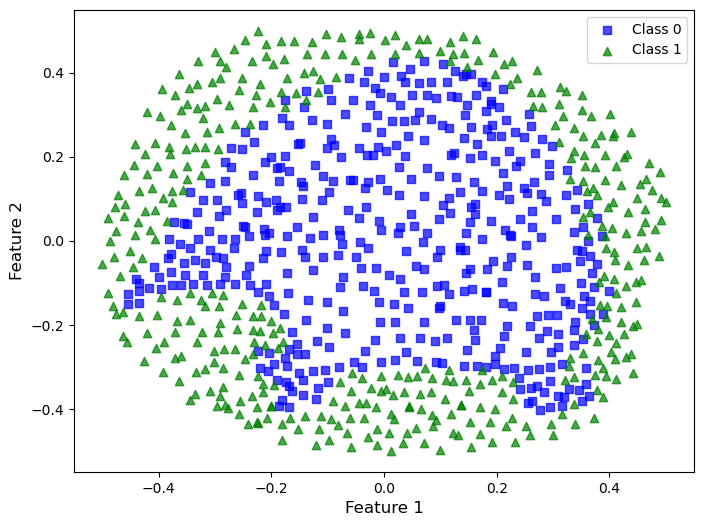

In [14]:
#seperate two class data
Y_ft = Y.flatten()
class_0 = X[Y_ft==0]
class_1 = X[Y_ft==1]


plt.figure(figsize=(8,6))
plt.scatter(class_0[:,0],class_0[:,1],color='blue',label='Class 0',marker='s',alpha=0.7)
plt.scatter(class_1[:,0],class_1[:,1],color='green',label='Class 1',marker='^',alpha=0.7)

plt.xlabel('Feature 1',fontsize=12)
plt.ylabel('Feature 2',fontsize=12)
plt.legend()
plt.show()

In [20]:
from keras.utils import to_categorical
from keras import Sequential
from keras.layers import Dense
from keras.optimizers import RMSprop

In [16]:
# dataset has 2 input variables, 2 output classes

#we will use to_categorical function from keras to convert label from 0 or 1 
# to 2-D array. Just like One hot encoding function
Y_train = to_categorical(Y_train)
Y_validation = to_categorical(Y_validation)

model = Sequential()
model.add(Dense(100,activation='sigmoid'))
model.add(Dense(2,activation='softmax'))


In [22]:
model.compile(loss='categorical_crossentropy',optimizer=RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

2025-10-30 19:19:35.861055: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-10-30 19:19:35.861180: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-30 19:19:35.861197: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-10-30 19:19:35.861541: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-30 19:19:35.861569: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
model.fit(X_train,Y_train,validation_data=(X_validation,Y_validation),
          epochs=30000,batch_size=25)

Epoch 1/30000


2025-10-30 19:22:13.180494: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.4912 - loss: 0.7771 - val_accuracy: 0.4807 - val_loss: 0.7001
Epoch 2/30000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5053 - loss: 0.6955 - val_accuracy: 0.5439 - val_loss: 0.6914
Epoch 3/30000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4912 - loss: 0.6961 - val_accuracy: 0.4807 - val_loss: 0.6939
Epoch 4/30000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4947 - loss: 0.6976 - val_accuracy: 0.6211 - val_loss: 0.6905
Epoch 5/30000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5123 - loss: 0.6945 - val_accuracy: 0.4807 - val_loss: 0.6909
Epoch 6/30000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5614 - loss: 0.6952 - val_accuracy: 0.5439 - val_loss: 0.6899
Epoch 7/30000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5333 - loss: 0.6960 - val_accuracy: 0.5789 - val_loss: 0.6890
Epoch 8/30000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5368 - loss: 0.6958 - val_accuracy: 

In [ ]:
#plot the boundry of trained model

from matplotlib.colors import ListedColormap

def plot_boundary(model,points):
    RANGE = 0.55
    x_mesh = np.average(-RANGE,RANGE,0.001)
    y_mesh = np.average(-RANGE,RANGE,0.001)
    grid_x,grid_y = np.meshgrid(x_mesh,y_mesh)
    grid = np.c_[grid_x.ravel(), grid_y.ravel()]

    classifications = model.predict(grid).argmax(axis=1)
    classifications_grid = classifications.reshape(grid_x.reshape)


    #Trace the decision boundary
    BLUE_AND_GREEN = ListedColormap(['#BBBBFF', '#BBFFBB'])
    plt.contourf(grid_x,grid_y,classifications_grid,camp=BLUE_AND_GREEN)

def plot_data_by_label(input_variables,labels,label_selector,symbol):
    points = input_variables[(labels == label_selector).flatten()]
    plt.plot(points[:,0], points[:,1],symbol,markersize=4)

def show(model,x,y,title="Decision boundary"):
    plot_boundary(model,x)
    plot_data_by_label(x,y,0,'bs')
    plot_data_by_label(x,y,1,'g^')
    plt.gca().axes.xaxis.set_ticklabels([])
    plt.gca().axes.yaxis.set_ticklabels([])
    plt.title(title,fontsize=15)
    plt.show()




In [ ]:
show(model,X_train,np.argmax(Y_train,axis=1))

In [ ]:
model2 = Sequential()
model2.add(Dense(100,activation='sigmoid'))
model2.add(Dense(30,activation='sigmoid'))
model2.add(Dense(2,activation='softmax'))

In [ ]:
model2.compile(loss='categorical_crossentropy',
                optimizer=RMSprop(learning_rate=0.001),
                metrics=['accuracy'])

In [ ]:
model2.fit(X_train,Y_train,validation_data=(X_validation,Y_validation),
epochs=1000,batch_size=25)

In [ ]:
show(model2,X_train,np.argmax(Y_train,axis=1))